In [1]:
from input_pipeline import preprocess_dataset, get_masked_dataset, batch_sampler
import xarray as xr
import jax.numpy as jnp
import jax
import chex
import numpy as np
import flax
import rich
import flax.linen as nn
import optax

### Load, Normalization & Masking

In [3]:
ds = xr.load_dataarray('../data/SiC_100x10.nc')
filtered_ds = preprocess_dataset(ds, verbose = True)
masked_ds = get_masked_dataset(filtered_ds)

Dropped 20 spectra


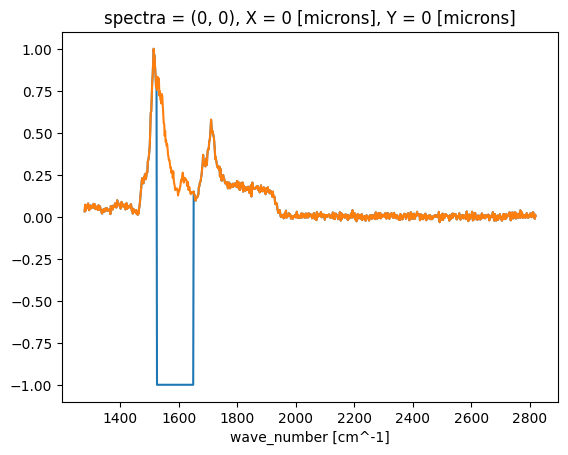

In [16]:
masked_ds.sel(spectra = (0,0)).plot()
filtered_ds.sel(spectra = (0,0)).plot()

In [53]:
# Transformer model. See "Formal algorithms for transformers" [arXiv:2207.09238 [cs.LG]] and "On Layer Normalization in the Transformer Architecture" [arXiv:2002.04745 [cs.LG]] and "An introduction to transformers" [arXiv:2304.10557 [cs.LG]].

class LinearProjection(nn.Module):
    """Linear embedding projection"""
    embedding_dim: int

    @nn.compact
    def __call__(self, x):
        x = nn.LayerNorm()(x)
        x = nn.Dense(self.embedding_dim, use_bias=False)(x)
        x = nn.LayerNorm()(x)
        return x
    
def test_LinearProjection():
    """Test LinearProjection"""
    x = np.random.randn(1, 2, 3, 100)
    model = LinearProjection(128)
    variables = model.init(jax.random.PRNGKey(0), x)
    y = model.apply(variables, x)
    chex.assert_shape(y, (1,2, 3, 128))
    chex.assert_shape(variables['params']['Dense_0']['kernel'], (100, 128))
test_LinearProjection()

class FFBlock(nn.Module):
    """Feed-forward block for transformer model"""
    embedding_dim: int
    dropout_rate: float

    @nn.compact
    def __call__(self, x, training: bool):
        x = nn.Dense(4*self.embedding_dim)(x)
        x = nn.relu(x)
        x = nn.Dense(self.embedding_dim)(x)
        x = nn.Dropout(self.dropout_rate, deterministic = not training)(x)
        return x

class TransformerEncoderLayer(nn.Module):
    """Transformer encoder layer"""
    embedding_dim: int
    num_heads: int
    dropout_rate: float

    @nn.compact
    def __call__(self, x, training: bool):
        # Multi-head attention
        x_norm = nn.LayerNorm()(x)
        x_norm = nn.MultiHeadDotProductAttention(
            num_heads = self.num_heads,
            qkv_features = self.embedding_dim,
            dropout_rate = self.dropout_rate
        )(x_norm, deterministic = not training)
        x = x + nn.Dense(self.embedding_dim)(x_norm)
        x = nn.Dropout(self.dropout_rate, deterministic = not training)(x)
        x_norm = nn.LayerNorm()(x)
        x_norm = FFBlock(self.embedding_dim, self.dropout_rate)(x_norm, training = training)
        x = x + nn.Dense(self.embedding_dim)(x_norm)
        return x
    
class SpectraFormer(nn.Module):
    embedding_dim: int
    num_heads: int
    num_layers: int
    dropout_rate: float = 0.1

    @nn.compact
    def __call__(self, counts, wave_number, training: bool = True):
        emb_counts = LinearProjection(self.embedding_dim)(counts)
        emb_wave_number = LinearProjection(self.embedding_dim)(wave_number)
        x = emb_counts + emb_wave_number
        for _ in range(self.num_layers):
            x = TransformerEncoderLayer(self.embedding_dim, self.num_heads, self.dropout_rate)(x, training = training)
        x = nn.LayerNorm()(x)
        x = nn.Dense(1)(x)
        return x

In [54]:
batch_size = 32
train_iter = batch_sampler(filtered_ds, masked_ds, batch_size = batch_size, shuffle = True, drop_last = True)
batch = next(train_iter)

model = SpectraFormer(embedding_dim = 32, num_heads =2, num_layers = 1)
root_key = jax.random.key(seed=0)
main_key, params_key, dropout_key = jax.random.split(key=root_key, num=3)

variables = model.init(params_key, batch['masked_spectra'][0], batch['wave_number'][0], training = False)
params = variables['params']

In [55]:
# Print model summary
# print(model.tabulate(root_key, counts = batch['masked_spectra'][0], wave_number = batch['wave_number'][0], training = False, compute_flops=True, compute_vjp_flops=True))

In [58]:
from flax.training import train_state
class TrainState(train_state.TrainState):
  key: jax.Array

In [64]:
@jax.jit
def train_step(state: TrainState, batch, dropout_key):
  dropout_train_key = jax.random.fold_in(key=dropout_key, data=state.step)
  def loss_fn(params):
    pred_spectra = state.apply_fn(
      {'params': params},
      batch['masked_spectra'], batch['wave_number'],
      training=True,
      rngs={'dropout': dropout_train_key}
      )
    loss = optax.squared_error(pred_spectra, batch['spectra']).mean()
    return loss
  grad_fn = jax.value_and_grad(loss_fn)
  loss, grads = grad_fn(state.params)
  state = state.apply_gradients(grads=grads)
  return state, loss

In [83]:
model = SpectraFormer(embedding_dim = 32, num_heads = 2, num_layers = 2)
root_key = jax.random.key(seed=0)
main_key, params_key, dropout_key = jax.random.split(key=root_key, num=3)

dummy_batch = next(batch_sampler(filtered_ds, masked_ds))
variables = model.init(params_key, dummy_batch['masked_spectra'][0], dummy_batch['wave_number'][0], training = False)
params = variables['params']


state = TrainState.create(
  apply_fn=jax.jit(model.apply, static_argnames='training'),
  params=params,
  key=dropout_key,
  tx=optax.adam(1e-4)
)

In [84]:
n_epochs = 3
train_loss = []
for epoch in range(n_epochs):
    train_iter = batch_sampler(filtered_ds, masked_ds, batch_size = 256, shuffle = True, drop_last = True, rng_seed = epoch)
    for batch in train_iter:
        state, _loss = train_step(state, batch, dropout_key)
        train_loss.append(_loss.item())

In [85]:
train_loss

[0.03282306715846062,
 0.2995631992816925,
 0.2821383774280548,
 0.27423161268234253,
 0.26921936869621277,
 0.26230794191360474,
 0.2559276223182678,
 0.2477821260690689,
 0.23776684701442719]

In [86]:
state.params['Linear']

{'Dense_0': {'bias': Array([0.00063643], dtype=float32),
  'kernel': Array([[-0.13200946],
         [ 0.3528872 ],
         [-0.195702  ],
         [-0.12663202],
         [ 0.29241037],
         [-0.22961712],
         [-0.21848868],
         [ 0.00670598],
         [-0.11293513],
         [-0.18997045],
         [ 0.06097226],
         [ 0.25479504],
         [ 0.25347644],
         [-0.3006129 ],
         [-0.104075  ],
         [ 0.12364259],
         [ 0.19142683],
         [-0.20073192],
         [-0.13600872],
         [ 0.01376779],
         [-0.04097836],
         [ 0.18605117],
         [-0.13691518],
         [-0.24088316],
         [ 0.02631801],
         [-0.2840965 ],
         [-0.0193054 ],
         [ 0.23066111],
         [-0.10237686],
         [ 0.04392278],
         [-0.10518242],
         [-0.1057911 ]], dtype=float32)},
 'LayerNorm_0': {'bias': Array([-0.00063644,  0.00063644, -0.00063644, -0.00063642,  0.00063646,
         -0.00063644, -0.00063644,  0.00063643, -0

In [35]:
from time import perf_counter
train_iter = batch_sampler(filtered_ds, masked_ds, batch_size = batch_size, shuffle = True, drop_last = True)
times = []
for batch in train_iter:
    _dt = perf_counter()
    state = train_step(state, batch, dropout_key)
    _dt = perf_counter() - _dt
    times.append(_dt)
times = np.array(times)
print(f"Batch size: {batch_size}, throughput: {batch_size / times.mean() * 1e-3:.2f} ksamples/s")

Batch size: 32, throughput: 0.08 ksamples/s


In [46]:
# Measure throughput at different batch sizes
batch_sizes = [8, 16, 32, 64, 128, 256]

for batch_size in batch_sizes:
    train_iter = batch_sampler(filtered_ds, masked_ds, batch_size = batch_size, shuffle = True, drop_last = True)
    rng = jax.random.PRNGKey(0)
    rng, init_rng = jax.random.split(rng)
    variables = model.init(init_rng, counts = batch['masked_spectra'][0], wave_number = batch['wave_number'][0], training = False)
    # Warmup
    batch = next(train_iter)
    apply_fn = jax.jit(model.apply, static_argnames='training')
    apply_fn(variables, batch['masked_spectra'], batch['wave_number'], training=True, rngs = {'dropout': rng})
    
    # Measure throughput
    times = []
    for batch in train_iter:
        _dt = perf_counter()
        out = apply_fn(variables, batch['masked_spectra'], batch['wave_number'], training=True, rngs = {'dropout': rng})
        _dt = perf_counter() - _dt
        times.append(_dt)
    times = np.array(times)
    print(f"Batch size: {batch_size}, throughput: {batch_size / times.mean():.0f} samples/s")

Batch size: 8, throughput: 122.301 samples/s
Batch size: 16, throughput: 148.181 samples/s
Batch size: 32, throughput: 152.113 samples/s
Batch size: 64, throughput: 160.564 samples/s
Batch size: 128, throughput: 140.939 samples/s
Batch size: 256, throughput: 113.553 samples/s
